In [5]:
import pandas as pd
import numpy as np
import re
import string

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer

from wordcloud import WordCloud

import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [7]:
comments = [
    "This product is amazing! I loved it.",
    "Worst service ever.",
    "Delivery was late but product quality is excellent.",
    "Very disappointed with customer support.",
    "Awesome experience. Highly recommended!",
    "Packaging was damaged.",
    "Excellent quality and fast delivery.",
    "Not worth the price.",
    "I will definitely buy again.",
    "Terrible experience.",
    "The product exceeded my expectations.",
    "Poor customer service.",
    "Fast shipping and great quality.",
    "I hate this product.",
    "Fantastic design and excellent performance.",
    "Waste of money.",
    "Highly satisfied with my purchase.",
    "The app is easy to use.",
    "The website is slow.",
    "Superb experience!"
]


In [8]:
df = pd.DataFrame(comments, columns=["Comment"])

print("\nOriginal Comments:\n")
print(df)


Original Comments:

                                              Comment
0                This product is amazing! I loved it.
1                                 Worst service ever.
2   Delivery was late but product quality is excel...
3            Very disappointed with customer support.
4             Awesome experience. Highly recommended!
5                              Packaging was damaged.
6                Excellent quality and fast delivery.
7                                Not worth the price.
8                        I will definitely buy again.
9                                Terrible experience.
10              The product exceeded my expectations.
11                             Poor customer service.
12                   Fast shipping and great quality.
13                               I hate this product.
14        Fantastic design and excellent performance.
15                                    Waste of money.
16                 Highly satisfied with my purchase.
17     

In [10]:

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+", "", text)

    # Remove mentions
    text = re.sub(r"@\w+", "", text)

    # Remove hashtags
    text = re.sub(r"#", "", text)

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Tokenize
    words = text.split()

    # Remove stopwords and Lemmatize
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    return " ".join(words)

# Apply cleaning
df["Cleaned_Text"] = df["Comment"].apply(clean_text)

print("\nCleaned Comments:\n")
print(df)



Cleaned Comments:

                                              Comment  \
0                This product is amazing! I loved it.   
1                                 Worst service ever.   
2   Delivery was late but product quality is excel...   
3            Very disappointed with customer support.   
4             Awesome experience. Highly recommended!   
5                              Packaging was damaged.   
6                Excellent quality and fast delivery.   
7                                Not worth the price.   
8                        I will definitely buy again.   
9                                Terrible experience.   
10              The product exceeded my expectations.   
11                             Poor customer service.   
12                   Fast shipping and great quality.   
13                               I hate this product.   
14        Fantastic design and excellent performance.   
15                                    Waste of money.   
16         

In [11]:
def get_sentiment(text):

    polarity = TextBlob(text).sentiment.polarity

    if polarity > 0:
        return "Positive"

    elif polarity < 0:
        return "Negative"

    else:
        return "Neutral"

# Apply Sentiment Analysis
df["Sentiment"] = df["Cleaned_Text"].apply(get_sentiment)

print("\nSentiment Analysis:\n")
print(df)


Sentiment Analysis:

                                              Comment  \
0                This product is amazing! I loved it.   
1                                 Worst service ever.   
2   Delivery was late but product quality is excel...   
3            Very disappointed with customer support.   
4             Awesome experience. Highly recommended!   
5                              Packaging was damaged.   
6                Excellent quality and fast delivery.   
7                                Not worth the price.   
8                        I will definitely buy again.   
9                                Terrible experience.   
10              The product exceeded my expectations.   
11                             Poor customer service.   
12                   Fast shipping and great quality.   
13                               I hate this product.   
14        Fantastic design and excellent performance.   
15                                    Waste of money.   
16       

In [12]:
vectorizer = CountVectorizer(stop_words="english")

X = vectorizer.fit_transform(df["Cleaned_Text"])

word_counts = pd.DataFrame({
    "Word": vectorizer.get_feature_names_out(),
    "Count": X.toarray().sum(axis=0)
})

word_counts = word_counts.sort_values(by="Count", ascending=False)

print("\nTop Trending Words:\n")
print(word_counts.head(10))



Top Trending Words:

          Word  Count
27     product      4
12   excellent      3
29     quality      3
14  experience      3
19      highly      2
32     service      2
16        fast      2
7     delivery      2
4     customer      2
2      awesome      1


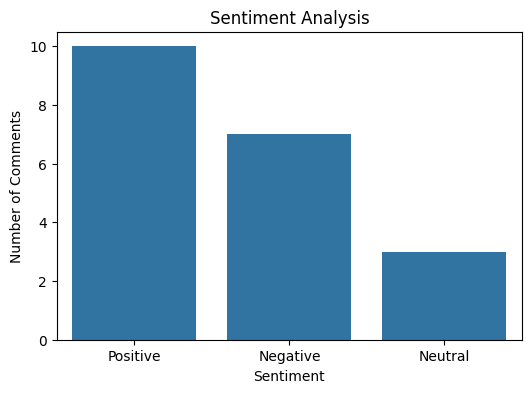

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(x="Sentiment", data=df)
plt.title("Sentiment Analysis")
plt.xlabel("Sentiment")
plt.ylabel("Number of Comments")
plt.show()


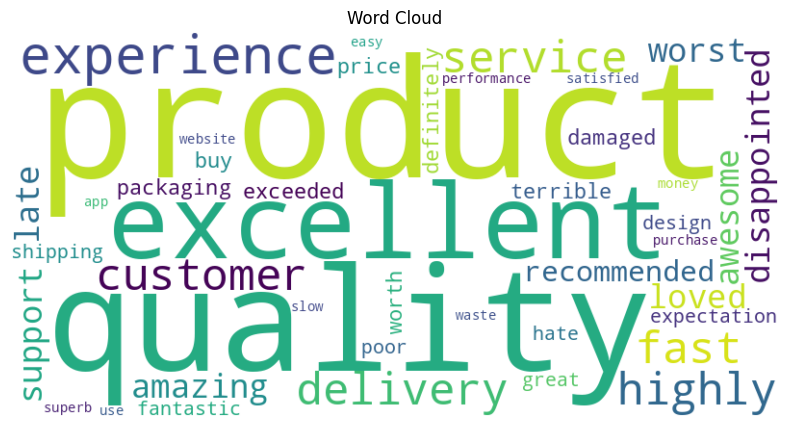

In [14]:
text = " ".join(df["Cleaned_Text"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud")
plt.show()


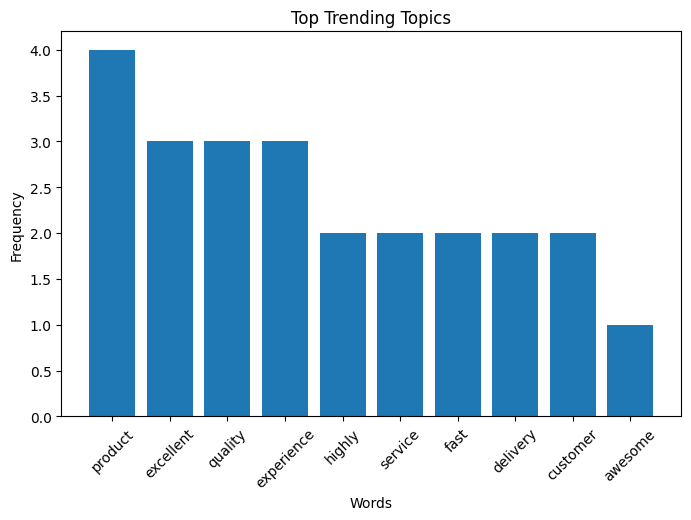

In [15]:
top_words = word_counts.head(10)

plt.figure(figsize=(8,5))
plt.bar(top_words["Word"], top_words["Count"])
plt.title("Top Trending Topics")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()


Sentiment Percentage:

Sentiment
Positive    50.0
Negative    35.0
Neutral     15.0
Name: proportion, dtype: float64


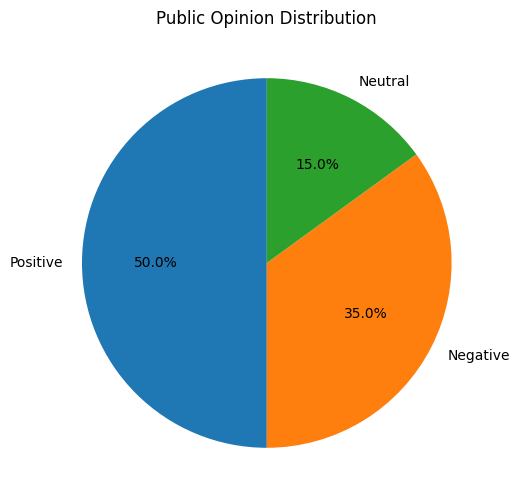

In [16]:
sentiment_percentage = (
    df["Sentiment"]
    .value_counts(normalize=True) * 100
)

print("\nSentiment Percentage:\n")
print(sentiment_percentage)

# Pie Chart
plt.figure(figsize=(6,6))
plt.pie(
    sentiment_percentage,
    labels=sentiment_percentage.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Public Opinion Distribution")
plt.show()

# New Section

In [17]:
print("\nFinal Dataset:\n")
print(df)

# Save to CSV
df.to_csv("social_media_sentiment_analysis.csv", index=False)

print("\nAnalysis completed successfully!")
print("Dataset saved as 'social_media_sentiment_analysis.csv'")


Final Dataset:

                                              Comment  \
0                This product is amazing! I loved it.   
1                                 Worst service ever.   
2   Delivery was late but product quality is excel...   
3            Very disappointed with customer support.   
4             Awesome experience. Highly recommended!   
5                              Packaging was damaged.   
6                Excellent quality and fast delivery.   
7                                Not worth the price.   
8                        I will definitely buy again.   
9                                Terrible experience.   
10              The product exceeded my expectations.   
11                             Poor customer service.   
12                   Fast shipping and great quality.   
13                               I hate this product.   
14        Fantastic design and excellent performance.   
15                                    Waste of money.   
16            